In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV, cross_val_score, learning_curve
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report,ConfusionMatrixDisplay

In [122]:
data = pd.read_csv("donne.csv")

In [123]:
data.head()

,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,normal
1,30.807200,5.459076,76.199180,13.944380,10.0,normal
2,15.723226,3.000000,60.280820,13.243565,10.0,normal
3,57.796256,10.103074,104.990471,14.105683,10.0,normal
4,40.321320,7.110583,85.277902,14.641630,10.0,normal


In [124]:
data.shape

(5000, 6)

In [125]:
data.isnull().mean()*100

age_months          0.0
weight_kg           0.0
height_cm           0.0
muac_cm             0.0
bmi                 0.0
nutrition_status    0.0
dtype: float64

In [126]:
data["nutrition_status"].unique()

<ArrowStringArray>
['normal', 'moderate', 'severe']
Length: 3, dtype: str

In [127]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age_months        5000 non-null   float64
 1   weight_kg         5000 non-null   float64
 2   height_cm         5000 non-null   float64
 3   muac_cm           5000 non-null   float64
 4   bmi               5000 non-null   float64
 5   nutrition_status  5000 non-null   str    
dtypes: float64(5), str(1)
memory usage: 265.9 KB


In [128]:
feature = data.select_dtypes(include ="float")
cat_feature = data.select_dtypes(include = "object")

C:\Users\dc\AppData\Local\Temp\ipykernel_20812\3165787018.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_feature = data.select_dtypes(include = "object")


In [129]:
colonne = feature.columns.tolist()
colonne

['age_months', 'weight_kg', 'height_cm', 'muac_cm', 'bmi']

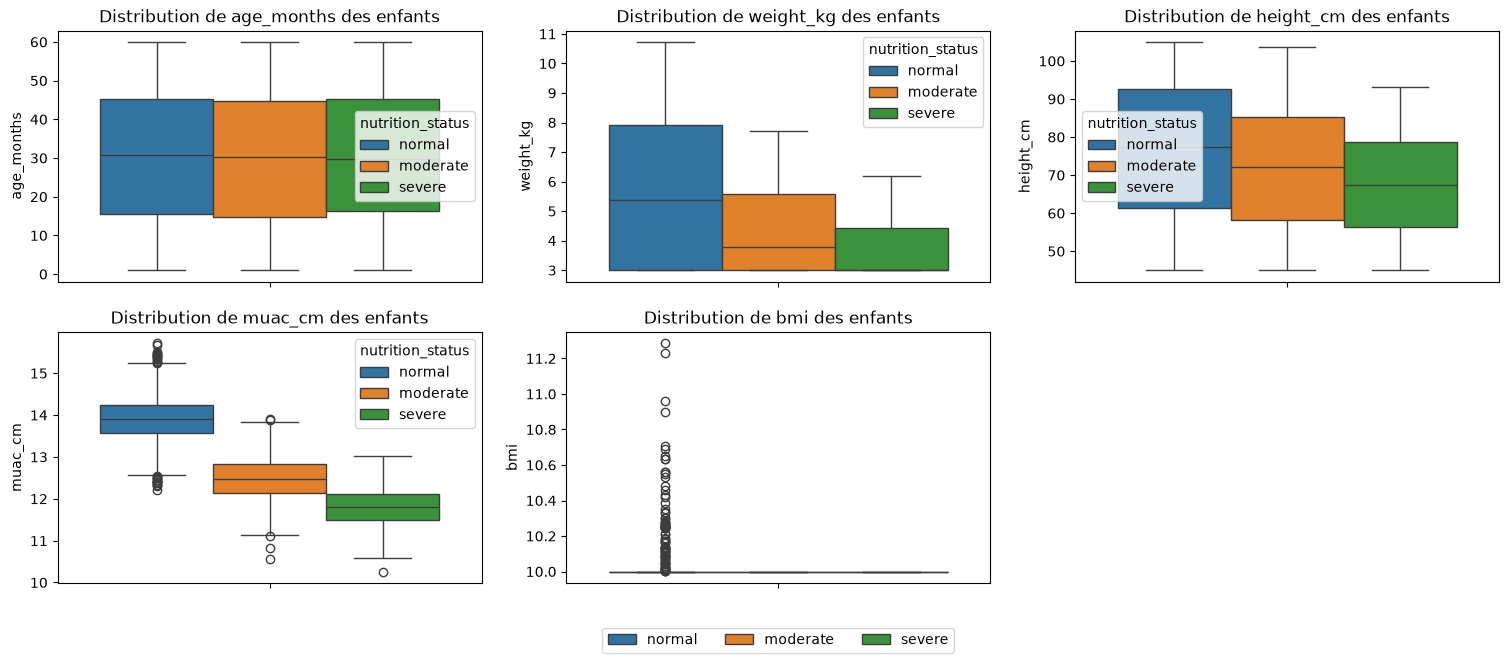

In [130]:
plt.figure(figsize= (18.6, 15))
for i in range(len(colonne)):
    plt.subplot(4, 3, i+1)
    plt.title(f"Distribution de {colonne[i]} des enfants")
    sns.boxplot(data = data, y = colonne[i], hue= "nutrition_status",)
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

In [131]:
encode = LabelEncoder()
for i in cat_feature:
    data[i] = encode.fit_transform(data[i])

In [132]:
data.head()

,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,1
1,30.807200,5.459076,76.199180,13.944380,10.0,1
2,15.723226,3.000000,60.280820,13.243565,10.0,1
3,57.796256,10.103074,104.990471,14.105683,10.0,1
4,40.321320,7.110583,85.277902,14.641630,10.0,1


<Axes: >

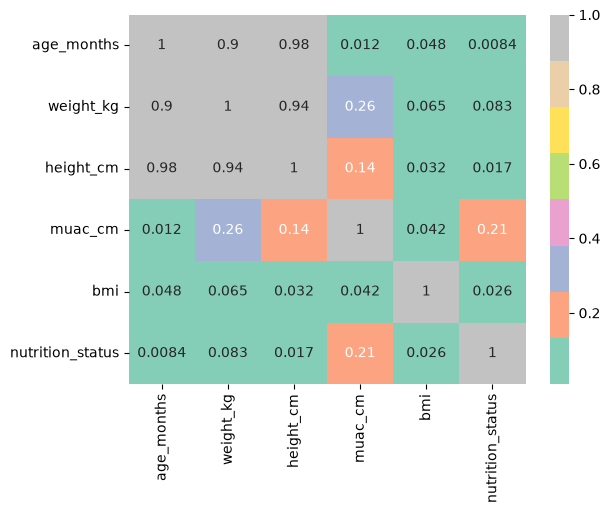

In [133]:
sns.heatmap(data.corr(numeric_only=True), annot = True, cmap ="Set2", alpha = 0.8)

In [134]:
X = data.drop(columns="nutrition_status")
y = data["nutrition_status"]

In [135]:
X

,age_months,weight_kg,height_cm,muac_cm,bmi
0,12.345052,3.000000,54.134002,13.160919,10.0
1,30.807200,5.459076,76.199180,13.944380,10.0
2,15.723226,3.000000,60.280820,13.243565,10.0
3,57.796256,10.103074,104.990471,14.105683,10.0
4,40.321320,7.110583,85.277902,14.641630,10.0
...,...,...,...,...,...
4995,36.397569,4.674426,79.668509,12.976748,10.0
4996,18.947724,3.371817,62.914947,13.806374,10.0
4997,37.636794,4.504413,77.793425,12.449221,10.0
4998,27.286957,4.799405,75.048627,14.152550,10.0


In [136]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4995    0
4996    1
4997    0
4998    1
4999    2
Name: nutrition_status, Length: 5000, dtype: int64

In [137]:
#Decoupage du dataset 

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.2)

In [138]:
print(f"- Entrainement :{X_train.shape}\n- Evaluation {X_test.shape}")

- Entrainement :(4000, 5)
- Evaluation (1000, 5)


In [139]:
##Essayosn de standardiser les donnes pour avant d'entrainer notre modl KNN

scale  = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

 ### - 1 Modele KNN

In [140]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
model_knn.score(X_train, y_train)

0.9655

Le score sur les donnees d'entrainment est `96 %`

In [141]:
#Entrainment sur les donnes de validation

val_score = cross_val_score(KNeighborsClassifier(), X_train, y_train, cv = 5)

In [142]:
val_score

array([0.945  , 0.94875, 0.94625, 0.96125, 0.9475 ])

In [143]:
val_score = val_score.mean()
val_score  #Pa de overfitting ou under c'est miexu mais le model a perdui un peu de sa performace 

np.float64(0.9497500000000001)

In [144]:
rang = np.arange(1, 50)
train_score, val_score  = validation_curve(model_knn, X_train, y_train, param_name= "n_neighbors",param_range= rang, cv = 5 )

In [145]:
moy_train = train_score.mean(axis = 1)

In [146]:
moy_train

array([1.       , 0.9720625, 0.97075  , 0.9636875, 0.964    , 0.9595625,
       0.961    , 0.958625 , 0.9579375, 0.9546875, 0.9558125, 0.9545625,
       0.9546875, 0.952875 , 0.953125 , 0.95175  , 0.952375 , 0.95075  ,
       0.9495625, 0.947625 , 0.94725  , 0.9456875, 0.945375 , 0.9444375,
       0.9440625, 0.942625 , 0.9429375, 0.941375 , 0.9406875, 0.9395625,
       0.9396875, 0.9380625, 0.938125 , 0.9370625, 0.937    , 0.9355625,
       0.93575  , 0.935125 , 0.934625 , 0.9338125, 0.9335   , 0.9329375,
       0.93325  , 0.93175  , 0.932375 , 0.93075  , 0.9305   , 0.9291875,
       0.9293125])

In [147]:
moy_val = val_score.mean(axis = 1)
moy_val

array([0.94425, 0.94075, 0.94875, 0.947  , 0.94975, 0.94825, 0.94975,
       0.94825, 0.94825, 0.947  , 0.947  , 0.94575, 0.9465 , 0.94675,
       0.94375, 0.944  , 0.94425, 0.9435 , 0.9445 , 0.944  , 0.9435 ,
       0.94225, 0.94125, 0.94025, 0.94025, 0.93825, 0.938  , 0.9365 ,
       0.93575, 0.9345 , 0.934  , 0.93325, 0.93325, 0.9315 , 0.9315 ,
       0.9305 , 0.92975, 0.92875, 0.929  , 0.927  , 0.92675, 0.927  ,
       0.92675, 0.9255 , 0.92575, 0.92625, 0.92525, 0.925  , 0.92475])

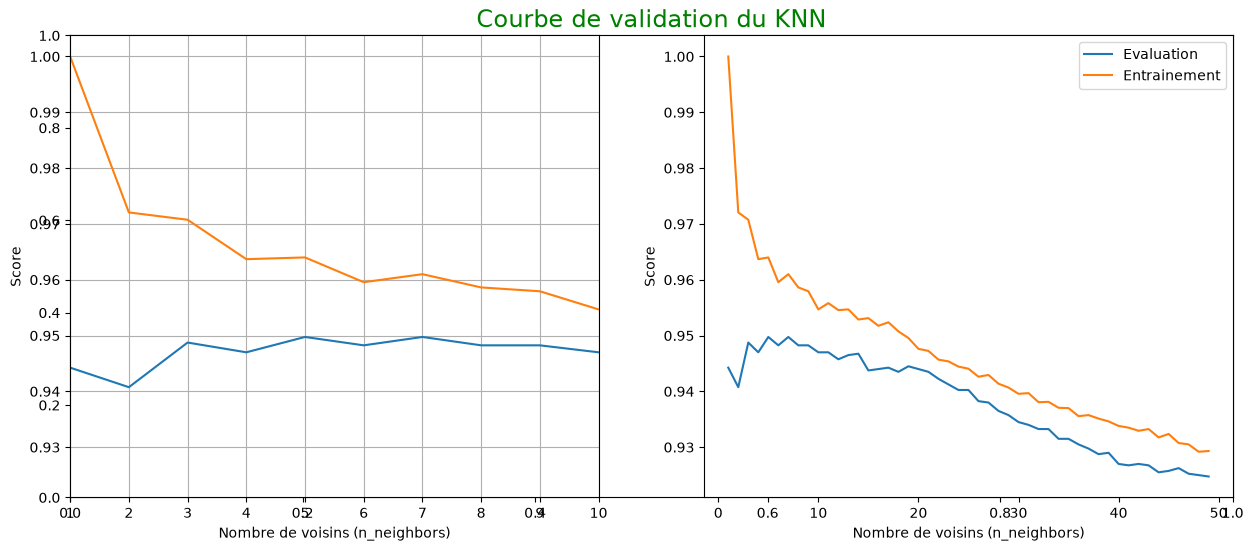

In [148]:
plt.figure(figsize= (15, 6))
plt.title("Courbe de validation du KNN", c = "green", size = 17)

plt.subplot(1,2,1)
plt.plot(rang, moy_val,  label = "Evaluation")
plt.plot(rang, moy_train,  label = "Entrainement")
plt.xlim(1,10)
plt.grid()
plt.xlabel("Nombre de voisins (n_neighbors)")
plt.ylabel("Score")

plt.subplot(1,2,2)
plt.plot(rang, moy_val,  label = "Evaluation")
plt.plot(rang, moy_train,  label = "Entrainement")

plt.xlabel("Nombre de voisins (n_neighbors)")
plt.ylabel("Score")
plt.legend()

In [149]:
param_grid = {
    "n_neighbors" : [2,4,5,6],
    "weights" : ["uniform", "distance"],
    "metric" : ["manhattan", "ecludean", "minkowski"]
}

grid = GridSearchCV(
    estimator= model_knn,
    param_grid = param_grid,
    n_jobs = -1,
    scoring = "accuracy",
    cv = 5
)

grid.fit(X_train, y_train)


C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Pyth

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['manhattan', 'ecludean', ...], 'n_neighbors': [2, 4, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, def

In [150]:
param = grid.best_params_
pd.DataFrame([param])

#Meilleur parametre du model KNN 

,metric,n_neighbors,weights
0,manhattan,6,distance


In [151]:
print(f"Meilleur score du model KNN: {grid.best_score_*100} %")

Meilleur score du model KNN: 95.075 %


In [152]:
KNN_best = grid.best_estimator_

In [153]:
#Visipn des erreur de prediction du modele 

confusion_matrix(y_test, KNN_best.predict(X_test))

array([[179,   8,  11],
       [  9, 725,   0],
       [ 19,   0,  49]])

In [154]:
train_sizes, train_score, val_score = learning_curve(KNN_best, X_train, y_train, train_sizes=np.linspace(0.1, 1.0,100), cv = 5 )

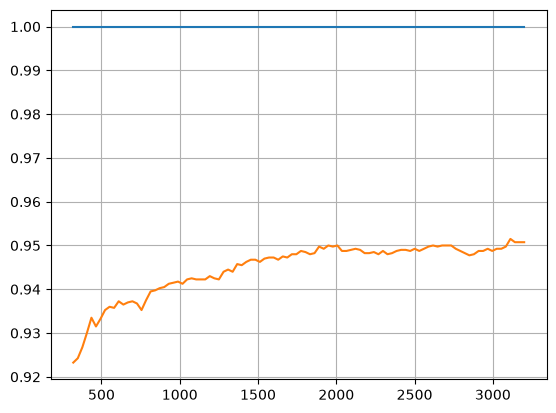

In [155]:
plt.plot(train_sizes, train_score.mean(axis = 1))
plt.plot(train_sizes, val_score.mean(axis = 1))
plt.grid()

In [156]:
y_pred = KNN_best.predict(X_test)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 Score  : {f1_score(y_test, y_pred, average = 'weighted'):.3f}")

Accuracy  : 0.953
F1 Score  : 0.953


In [157]:
metrique = classification_report(y_test, y_pred, output_dict = True)
pd.DataFrame(metrique).transpose().round(3)

,precision,recall,f1-score,support
0,0.865,0.904,0.884,198.000
1,0.989,0.988,0.988,734.000
2,0.817,0.721,0.766,68.000
accuracy,0.953,0.953,0.953,0.953
macro avg,0.890,0.871,0.879,1000.000
weighted avg,0.953,0.953,0.953,1000.000


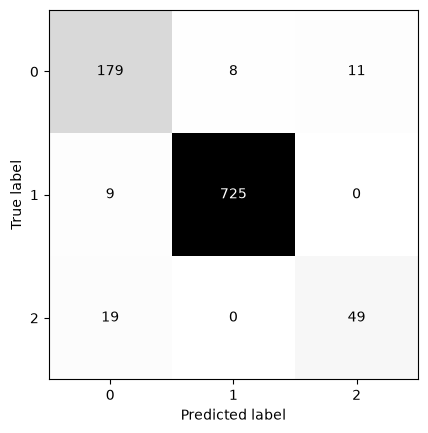

In [158]:
matrice = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=KNN_best.classes_)
matrice.plot(cmap = "Greys", colorbar = False)


## Model Decision Tree

In [159]:
model_ABR = DecisionTreeClassifier() #Initialisation du model de DecisionTreeClassifier

In [160]:
model_ABR.fit(X_train, y_train)
print(f"\nScore du model ABR sur les données d'entraînement : {model_ABR.score(X_train, y_train)}")


Score du model ABR sur les données d'entraînement : 1.0


In [161]:
val_score_ABR = cross_val_score(model_ABR, X_train, y_train, cv = 5)
print(f"\nScore de validation  ABR : {val_score_ABR}")
print(f"\nScore de validation croisée du model ABR : {val_score_ABR.mean()}")


Score de validation  ABR : [0.91375 0.91375 0.90375 0.92125 0.9175 ]

Score de validation croisée du model ABR : 0.914


In [162]:
train_score , val_score = validation_curve(model_ABR, X_train, y_train, param_name= "max_depth",param_range= np.arange(1, 50), cv = 5 )

In [163]:
train_score.mean(axis = 1)

array([0.870375 , 0.8811875, 0.8911875, 0.902625 , 0.90825  , 0.927125 ,
       0.9354375, 0.944375 , 0.95275  , 0.9595   , 0.9670625, 0.9729375,
       0.9794375, 0.9850625, 0.989375 , 0.9925625, 0.995375 , 0.9964375,
       0.9976875, 0.998625 , 0.9990625, 0.99925  , 0.9996875, 0.999875 ,
       0.99975  , 1.       , 0.9999375, 0.9999375, 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
       1.       ])

In [164]:
val_score.mean(axis = 1)

array([0.86925, 0.8785 , 0.887  , 0.89325, 0.89725, 0.9095 , 0.909  ,
       0.913  , 0.9185 , 0.91425, 0.9165 , 0.91525, 0.9165 , 0.9145 ,
       0.916  , 0.916  , 0.91625, 0.91575, 0.91625, 0.91175, 0.91425,
       0.91275, 0.91425, 0.911  , 0.913  , 0.91275, 0.91275, 0.91375,
       0.9125 , 0.91225, 0.91225, 0.91375, 0.91475, 0.91325, 0.913  ,
       0.911  , 0.914  , 0.91175, 0.912  , 0.91175, 0.9115 , 0.91175,
       0.9135 , 0.9115 , 0.91225, 0.91375, 0.91425, 0.913  , 0.9105 ])

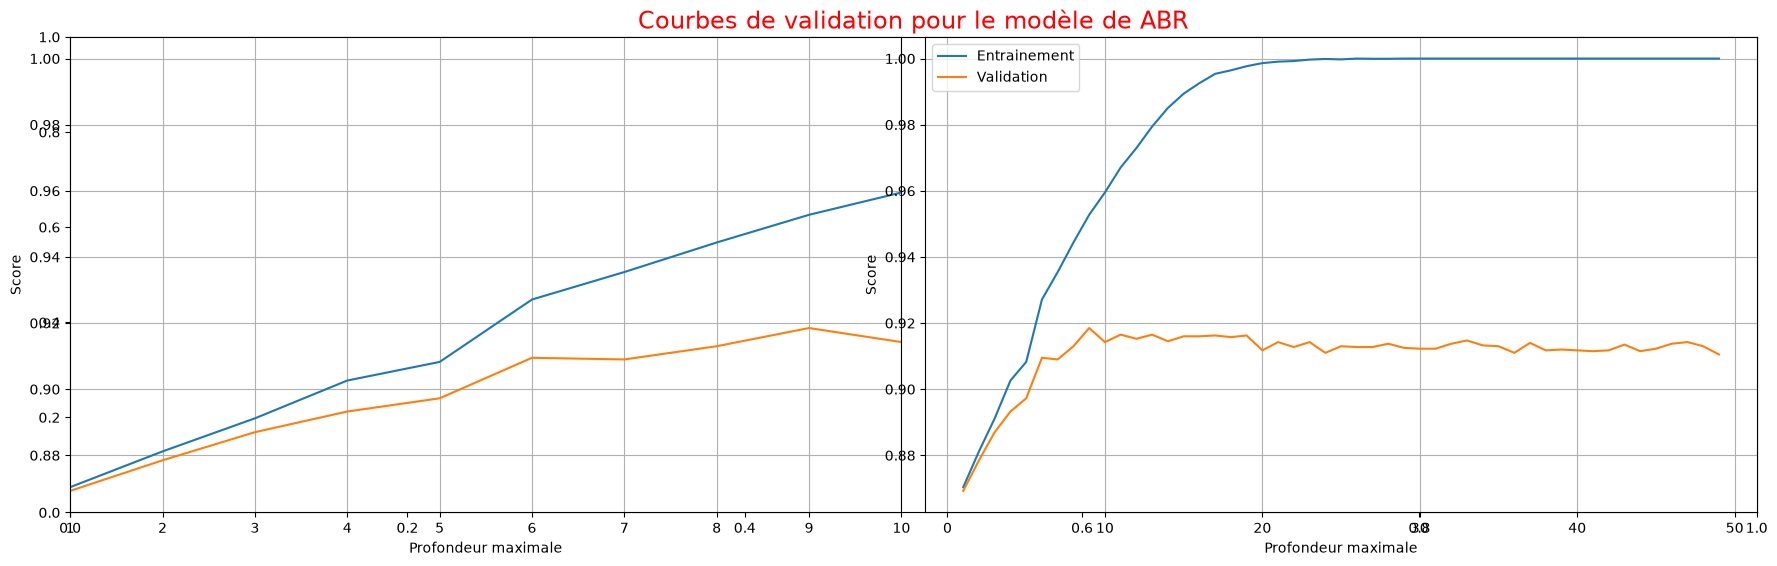

In [179]:
plt.figure(figsize= (18, 6))
plt.title("Courbes de validation pour le modèle de ABR", size = 17 , c= 'red')
plt.subplot(1,2,1)
plt.plot(np.arange(1, 50), train_score.mean(axis = 1), label = "Entrainement")
plt.plot(np.arange(1, 50), val_score.mean(axis = 1), label = "Validation")
plt.grid(True)
plt.xlim(1, 10)
plt.xlabel("Profondeur maximale")
plt.tight_layout()
plt.ylabel("Score")

plt.subplot(1,2,2)
plt.plot(np.arange(1, 50), train_score.mean(axis = 1), label = "Entrainement")
plt.plot(np.arange(1, 50), val_score.mean(axis = 1), label = "Validation")
plt.grid()
plt.xlabel("Profondeur maximale")
plt.ylabel("Score")

plt.legend()
plt.show()

- de ce que je vois graphiquement le model de ABR donne un meilleur score pour une profonduer maximum = 9, pour un score compris entre [0.90, 0.92]

In [180]:
## Detemination du meilleeur estimateur 

param_grid = {
    "max_depth" : [2, 4, 5, 6, 7, 9, 10],
    "min_samples_split" : [2,4,5,6,7,10],
    "criterion"  :["gini", "entropy", "log_loss"]
}

In [181]:
grid_abr  = GridSearchCV(
    estimator = model_ABR, 
    param_grid = param_grid, 
    n_jobs = -1,
    scoring = "accuracy",
    cv = 5  
)

In [182]:
grid_abr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 4, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=

In [172]:
print(f"Meilleurt score : {grid_abr.best_score_}\nparamètres optimaux : {grid_abr.best_params_}")

Meilleurt score : 0.93025
paramètres optimaux : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}


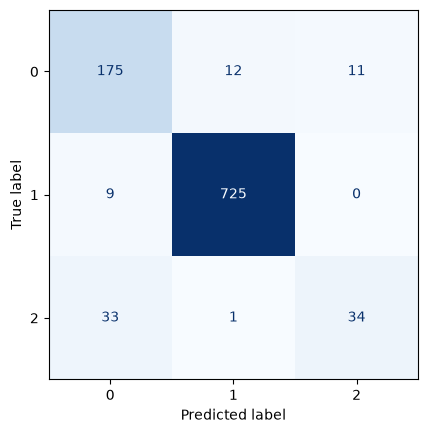

In [189]:
#Matrice de confusion du model ABR
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, grid_abr.predict(X_test)),
    display_labels=grid_abr.classes_).plot(cmap = "Blues", colorbar = False)

In [190]:
rapport = classification_report(y_test, grid_abr.predict(X_test), output_dict = True)
pd.DataFrame(rapport).transpose().round(3)

,precision,recall,f1-score,support
0,0.806,0.884,0.843,198.000
1,0.982,0.988,0.985,734.000
2,0.756,0.500,0.602,68.000
accuracy,0.934,0.934,0.934,0.934
macro avg,0.848,0.791,0.810,1000.000
weighted avg,0.932,0.934,0.931,1000.000
